# Flight Fare Prediction Project

## Problem Statement

Flight ticket prices are highly unpredictable.  
A flight ticket may cost ₹5000 today and ₹7000 tomorrow for the same route.  
There are multiple factors like the airline, number of stops, time of journey, duration, and others that influence the price.

Airlines want to predict optimal prices to maximize profits.  
Customers want to predict flight fares to plan cheaper bookings.

Thus, the goal is:

**Build a Machine Learning model that can predict the price of a flight given its details.**


##  Dataset Overview

We are provided with a dataset containing flight details such as:

| Feature | Description |
|:--------|:------------|
| `Airline` | Name of the Airline (e.g., IndiGo, Air India) |
| `Date_of_Journey` | Date when the journey starts |
| `Source` | City where the flight takes off |
| `Destination` | City where the flight lands |
| `Route` | Flight path taken to reach destination |
| `Dep_Time` | Departure time from source city |
| `Arrival_Time` | Arrival time at destination city |
| `Duration` | Total journey time |
| `Total_Stops` | Number of stops between source and destination |
| `Additional_Info` | Extra information about the flight |
| `Price` | Final ticket price (Target Variable) |


## Objective

- Perform detailed **Exploratory Data Analysis (EDA)** to understand the data.
- Preprocess the data (handling missing values, encoding categorical variables, feature extraction).
- Build and compare multiple Machine Learning models to predict flight fares.
- Select the best-performing model based on evaluation metrics.


## Importing Necessary Libraries :

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.linear_model import LinearRegression,Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
import os
%load_ext autoreload
%autoreload 2
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
print("Libraries Imported Successfully!")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Libraries Imported Successfully!


## Load the Dataset :

In [89]:
from utils import load_dataset
try:
    df=load_dataset('Flight_Fare.xlsx')
except Exception as error:
    print(f'Exception occuerd : {error}')

Excel Dataset Loaded Successfully!
 Dataset Shape: 10683 rows and 11 columns.


## **Basic Data Checks**

Before diving into data cleaning or modeling, we conduct initial checks to understand the structure and quality of the dataset. This includes:

- Viewing sample rows
- Checking dataset shape and column names
- Inspecting data types
- Identifying missing values
- Generating summary statistics
- Detecting object-type (categorical) features
- Checking for duplicate entries


In [90]:
# Show first 5 rows
display(df.head().to_string)

# Shape of the dataset
print(f"\nDataset Shape: {df.shape[0]} rows and {df.shape[1]} columns")

# Column names
print("\nColumn Names:")
print(df.columns.tolist())

# Data types
print("\nData Types:")
print(df.dtypes)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Summary statistics
print("\nSummary Statistics:")
display(df.describe().to_string)

# Object type columns (Categorical features)
print("\nCategorical Columns:")
print(df.columns[df.dtypes == 'object'].tolist())

# Check for duplicate rows
print(f"\nDuplicate Rows: {df.duplicated().sum()}")


<bound method DataFrame.to_string of        Airline Date_of_Journey    Source Destination                  Route  \
0       IndiGo      24/03/2019  Banglore   New Delhi              BLR → DEL   
1    Air India       1/05/2019   Kolkata    Banglore  CCU → IXR → BBI → BLR   
2  Jet Airways       9/06/2019     Delhi      Cochin  DEL → LKO → BOM → COK   
3       IndiGo      12/05/2019   Kolkata    Banglore        CCU → NAG → BLR   
4       IndiGo      01/03/2019  Banglore   New Delhi        BLR → NAG → DEL   

  Dep_Time  Arrival_Time Duration Total_Stops Additional_Info  Price  
0    22:20  01:10 22 Mar   2h 50m    non-stop         No info   3897  
1    05:50         13:15   7h 25m     2 stops         No info   7662  
2    09:25  04:25 10 Jun      19h     2 stops         No info  13882  
3    18:05         23:30   5h 25m      1 stop         No info   6218  
4    16:50         21:35   4h 45m      1 stop         No info  13302  >


Dataset Shape: 10683 rows and 11 columns

Column Names:
['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route', 'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops', 'Additional_Info', 'Price']

Data Types:
Airline            object
Date_of_Journey    object
Source             object
Destination        object
Route              object
Dep_Time           object
Arrival_Time       object
Duration           object
Total_Stops        object
Additional_Info    object
Price               int64
dtype: object

Missing Values:
Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

Summary Statistics:


<bound method DataFrame.to_string of               Price
count  10683.000000
mean    9087.064121
std     4611.359167
min     1759.000000
25%     5277.000000
50%     8372.000000
75%    12373.000000
max    79512.000000>


Categorical Columns:
['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route', 'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops', 'Additional_Info']

Duplicate Rows: 220


## Basic Data Checks

### 1. Dataset Shape:
- The dataset contains **10,683 rows** and **11 columns**.

### 2. Column Names:
The dataset includes the following columns:
- `Airline`
- `Date_of_Journey`
- `Source`
- `Destination`
- `Route`
- `Dep_Time`
- `Arrival_Time`
- `Duration`
- `Total_Stops`
- `Additional_Info`
- `Price` (target variable)

### 3. Data Types:
- **Categorical Features**:
  - `Airline`, `Date_of_Journey`, `Source`, `Destination`, `Route`, `Dep_Time`, `Arrival_Time`, `Duration`, `Total_Stops`, `Additional_Info`
  
- **Numerical Features**:
  - `Price` (integer)

### 4. Missing Values:
- There are missing values in:
  - `Route`: 1 missing value
  - `Total_Stops`: 1 missing value

### 5. Summary Statistics:
- **Price** (target variable) has the following statistics:
  - **Mean** price: ₹9,087
  - **Standard deviation**: ₹4,611
  - **Minimum price**: ₹1,759
  - **Maximum price**: ₹79,512

### 6. Categorical Columns:
- All columns, except for `Price`, are categorical and contain non-numeric data.

### 7. Duplicate Rows:
- There are **220 duplicate rows** in the dataset.


###  Data Cleaning & Preprocessing:

In [91]:
df.loc[df[['Total_Stops', 'Route']].isnull().any(axis=1)]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
9039,Air India,6/05/2019,Delhi,Cochin,NaN,09:45,09:25 07 May,23h 40m,NaN,No info,7480


In [92]:
# There is one record with two NAN values with two different featuers so,we are dropping that record:
df.dropna(inplace=True)
print("\nMissing Values After Preprocessing:")
print(df.isnull().sum())


Missing Values After Preprocessing:
Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64


In [93]:
# Removing Duplicate Rows :
#Before removing duplicate records :
df.drop_duplicates()
print(f"\nDuplicate Rows Before Removal: {df.duplicated().sum()}")
#After removing duplicate records:
df.drop_duplicates(inplace=True)
print(f"\nDuplicate Rows After Removal: {df.duplicated().sum()}")


Duplicate Rows Before Removal: 220

Duplicate Rows After Removal: 0


In [94]:
# Converting Date_of_Journey, Dep_Time, and Arrival_Time to datetime and extracting meaningful featuers:
df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'], format='%d/%m/%Y')
df["Journey_day"]=df['Date_of_Journey'].dt.day
df["Journey_month"]=df['Date_of_Journey'].dt.month
df.drop(columns=['Date_of_Journey'],inplace=True)

df['Dep_Time'] = pd.to_datetime(df['Dep_Time'], format='%H:%M')
df['Dep_Time(Hour)']=df['Dep_Time'].dt.hour
df['Dep_Time(Min)']=df['Dep_Time'].dt.minute
df.drop(columns='Dep_Time',inplace=True)

df['Arrival_Time(Hour)']=df['Arrival_Time'].str.strip().str.split().str[0].str.split(':').str[0]
df['Arrival_Time(Minute)']=df['Arrival_Time'].str.strip().str.split().str[0].str.split(':').str[1]
df.drop(columns='Arrival_Time',inplace=True)

df['Duration(Hour)']=df['Duration'].str.strip().str.split().str[0].str.replace('h','')
df['Duration(Hour)']=df['Duration(Hour)'].str.replace('m','')
df['Duration(Min)']=df['Duration'].str.strip().str.split().str[1].str.replace('m','')
df['Duration(Min)'].fillna('00',inplace=True)
df.drop(columns='Duration',inplace=True)

df.head()


,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Dep_Time(Hour),Dep_Time(Min),Arrival_Time(Hour),Arrival_Time(Minute),Duration(Hour),Duration(Min)
0,IndiGo,Banglore,New Delhi,BLR → DEL,non-stop,No info,3897,24,3,22,20,01,10,2,50
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2 stops,No info,7662,1,5,5,50,13,15,7,25
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2 stops,No info,13882,9,6,9,25,04,25,19,00
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1 stop,No info,6218,12,5,18,5,23,30,5,25
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,1 stop,No info,13302,1,3,16,50,21,35,4,45


In [95]:
# convert datatypes of misclasified featuers :
df.dtypes

Airline                 object
Source                  object
Destination             object
Route                   object
Total_Stops             object
Additional_Info         object
Price                    int64
Journey_day              int32
Journey_month            int32
Dep_Time(Hour)           int32
Dep_Time(Min)            int32
Arrival_Time(Hour)      object
Arrival_Time(Minute)    object
Duration(Hour)          object
Duration(Min)           object
dtype: object

In [96]:
columns=['Arrival_Time(Hour)', 'Arrival_Time(Minute)', 'Duration(Hour)', 'Duration(Min)','Price']

In [97]:
import importlib
import utils
importlib.reload(utils)


<module 'utils' from 'f:\\Machine_Learning\\Ml_Projects\\Flight Price Prediction Project\\notebooks\\utils.py'>

In [98]:
from utils import convert_dtypes
df=convert_dtypes(df,columns)

In [99]:
df.dtypes

Airline                 object
Source                  object
Destination             object
Route                   object
Total_Stops             object
Additional_Info         object
Price                    int32
Journey_day              int32
Journey_month            int32
Dep_Time(Hour)           int32
Dep_Time(Min)            int32
Arrival_Time(Hour)       int32
Arrival_Time(Minute)     int32
Duration(Hour)           int32
Duration(Min)            int32
dtype: object

#  Exploratory Data Analysis (EDA) :

## 1. Univariate Analysis

In this section, we will explore individual features using plots such as bar plots, histograms, and pie charts for categorical and numerical features.


## 2. Bivariate Analysis

Here, we explore how two features relate, especially with our target variable `Price`.


## 3. Multivariate Analysis

Visualize how more than two variables interact with each other and affect the target.


## 4. Correlation Analysis

Use a heatmap to check the strength of relationships between numerical variables.


## 5. Outlier Analysis

Visual inspection of extreme values that could affect model performance.


## 6. Key Insights

Summarize important findings from EDA to use during Feature Engineering and Modeling.


In [100]:
df

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Dep_Time(Hour),Dep_Time(Min),Arrival_Time(Hour),Arrival_Time(Minute),Duration(Hour),Duration(Min)
0,IndiGo,Banglore,New Delhi,BLR → DEL,non-stop,No info,3897,24,3,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2 stops,No info,7662,1,5,5,50,13,15,7,25
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2 stops,No info,13882,9,6,9,25,4,25,19,0
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1 stop,No info,6218,12,5,18,5,23,30,5,25
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,1 stop,No info,13302,1,3,16,50,21,35,4,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,CCU → BLR,non-stop,No info,4107,9,4,19,55,22,25,2,30
10679,Air India,Kolkata,Banglore,CCU → BLR,non-stop,No info,4145,27,4,20,45,23,20,2,35
10680,Jet Airways,Banglore,Delhi,BLR → DEL,non-stop,No info,7229,27,4,8,20,11,20,3,0
10681,Vistara,Banglore,New Delhi,BLR → DEL,non-stop,No info,12648,1,3,11,30,14,10,2,40


In [101]:
numerical_columns=df.select_dtypes(exclude='O').columns
categorical_columns=df.select_dtypes(include='O').columns

In [102]:
len(numerical_columns)#9
len(categorical_columns)#7

6

In [103]:
df[categorical_columns]['Total_Stops'].value_counts()

Total_Stops
1 stop      5625
non-stop    3475
2 stops     1318
3 stops       43
4 stops        1
Name: count, dtype: int64

In [104]:
df[categorical_columns]['Additional_Info'].value_counts()

Additional_Info
No info                         8182
In-flight meal not included     1926
No check-in baggage included     318
1 Long layover                    19
Change airports                    7
Business class                     4
No Info                            3
1 Short layover                    1
Red-eye flight                     1
2 Long layover                     1
Name: count, dtype: int64

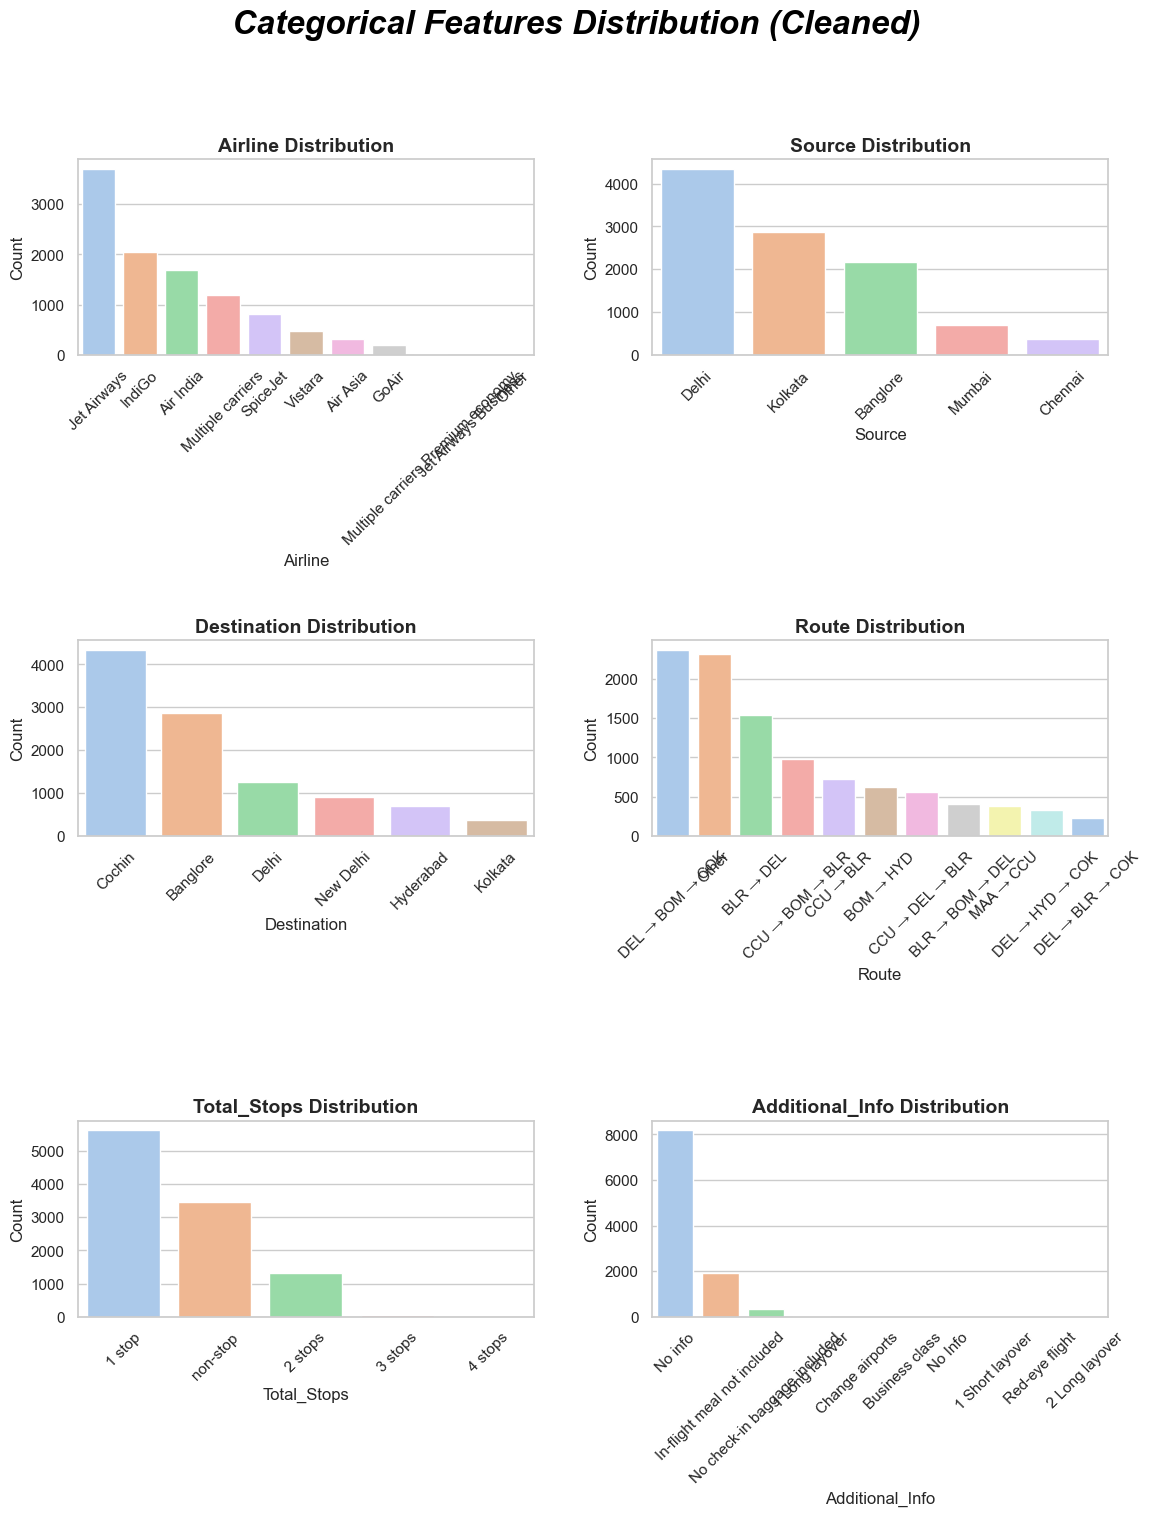

In [105]:
from utils import numeric_univariate_analysis,categorical_univariate_analysis_clean
categorical_univariate_analysis_clean(df,categorical_columns)

## Categorical Features - Univariate Analysis Insights

### Airline
- Jet Airways has the highest number of flights, followed by IndiGo and Air India.
- Airlines like Air Asia and GoAir have relatively fewer flights.
- A few rare airlines have very low frequency, indicating potential sparsity.

### Source
- Delhi is the most common source city, followed by Kolkata and Bangalore.
- Mumbai and Chennai have fewer flights compared to other source cities.

### Destination
- Cochin is the most frequent destination, followed by Bangalore and Delhi.
- Destinations like Kolkata and Hyderabad are comparatively less common.

### Route
- Certain specific routes (e.g., DEL → BOM → COK, BLR → DEL) are highly traveled.
- A small number of unique routes dominate the dataset.

### Total_Stops
- The majority of flights have either 1 stop or are non-stop flights.
- Flights with 2 or more stops are relatively rare.

### Additional_Info
- Most entries have 'No Info' under Additional_Info.
- In-flight meal not included and No check-in baggage included are some additional remarks but occur far less frequently.
- Other special categories like Business Class, Red-eye flight, and 1 or 2 Long layovers are extremely rare.


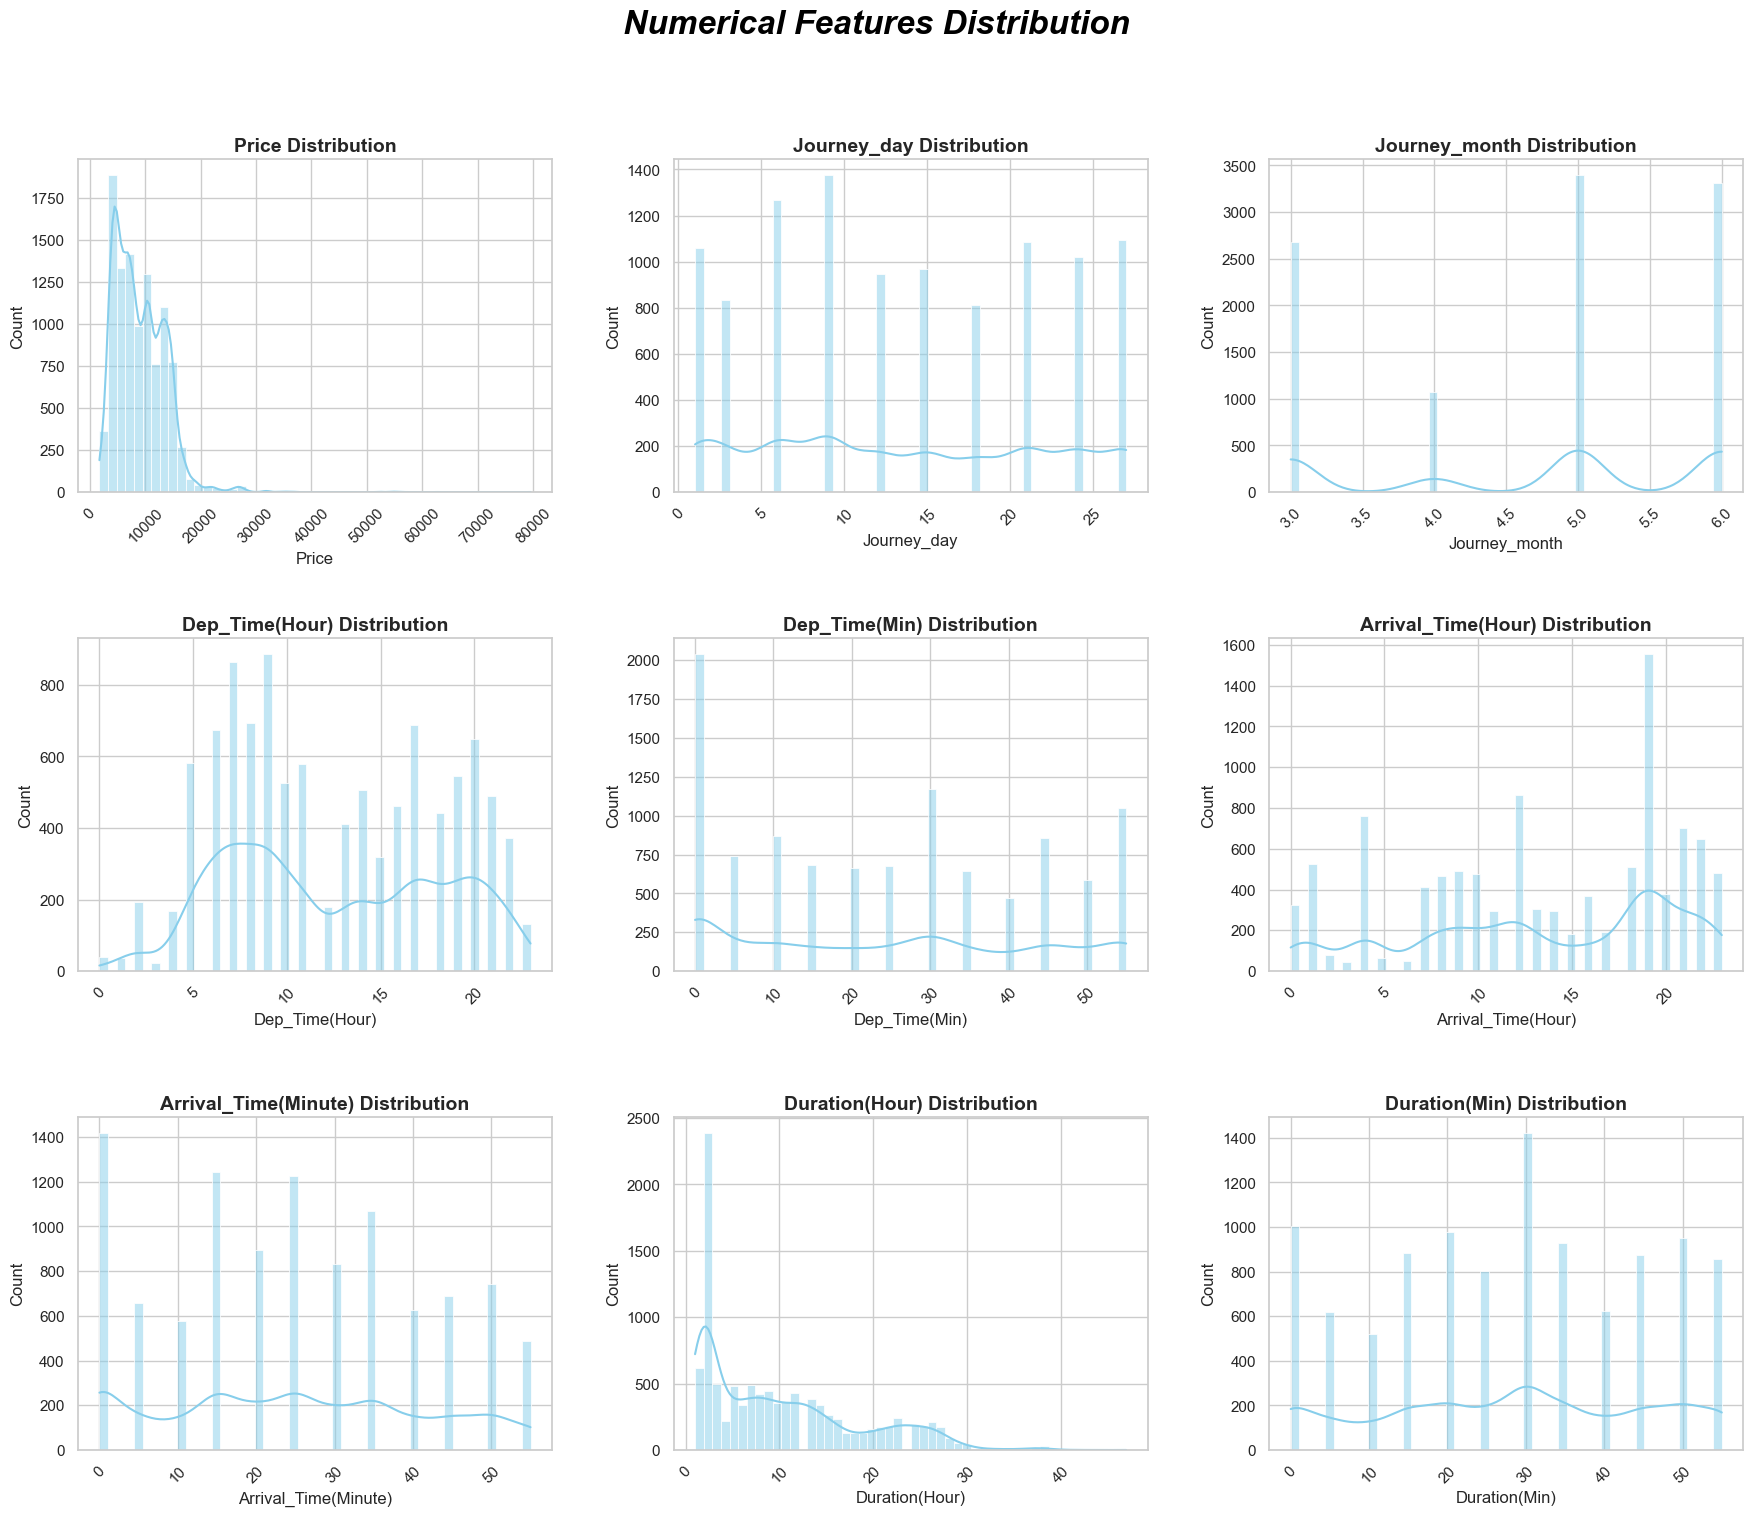

In [106]:
numeric_univariate_analysis(df,numerical_columns,numerical_columns)

## Numerical Features - Univariate Analysis Insights

### Price
- The distribution is right-skewed.
- Most flight prices are between 2000 and 10000.
- Some extreme outliers exist above 30000, requiring special handling.

### Journey_day
- Flight counts vary across different days of the month.
- Peaks observed around days like 1st, 9th, 18th, and 24th, suggesting uneven travel behavior across the month.

### Journey_month
- Only data from March to June is present.
- Most flights occur in May and June, indicating a seasonal pattern focused on the summer months.

### Dep_Time(Hour)
- Peak departure hours are early morning (5-8 AM) and evening (5-11 PM).
- Very few flights depart during late night or midnight hours.

### Dep_Time(Minute)
- Departure minutes are almost uniformly distributed.
- No significant peaks at particular minutes, suggesting minute-level departure time has less impact.

### Arrival_Time(Hour)
- Arrival peaks occur in early morning (6-8 AM) and evening (6-11 PM).
- Very few arrivals during midnight or early night.

### Arrival_Time(Minute)
- Similar to departure minutes, arrival minutes are fairly uniformly distributed.

### Duration(Hour)
- Most flight durations are between 1 to 5 hours.
- Some extremely long durations (above 30 hours) may need outlier treatment.

### Duration(Minute)
- Duration minutes are scattered across values without strong dominance.
- Duration in hours is more critical than minutes for modeling.


## Key Observations and Recommendations

- Many distributions are skewed, requiring possible transformation (e.g., log transformation on Price).
- Outliers present in Price and Duration must be handled carefully.
- Time-related features (Departure and Arrival Hours) are highly important, while Minutes are less impactful.
- Seasonality based on Journey Month should be considered during model training and validation.
- Rare categories in categorical variables may be grouped under an 'Other' label or treated appropriately.



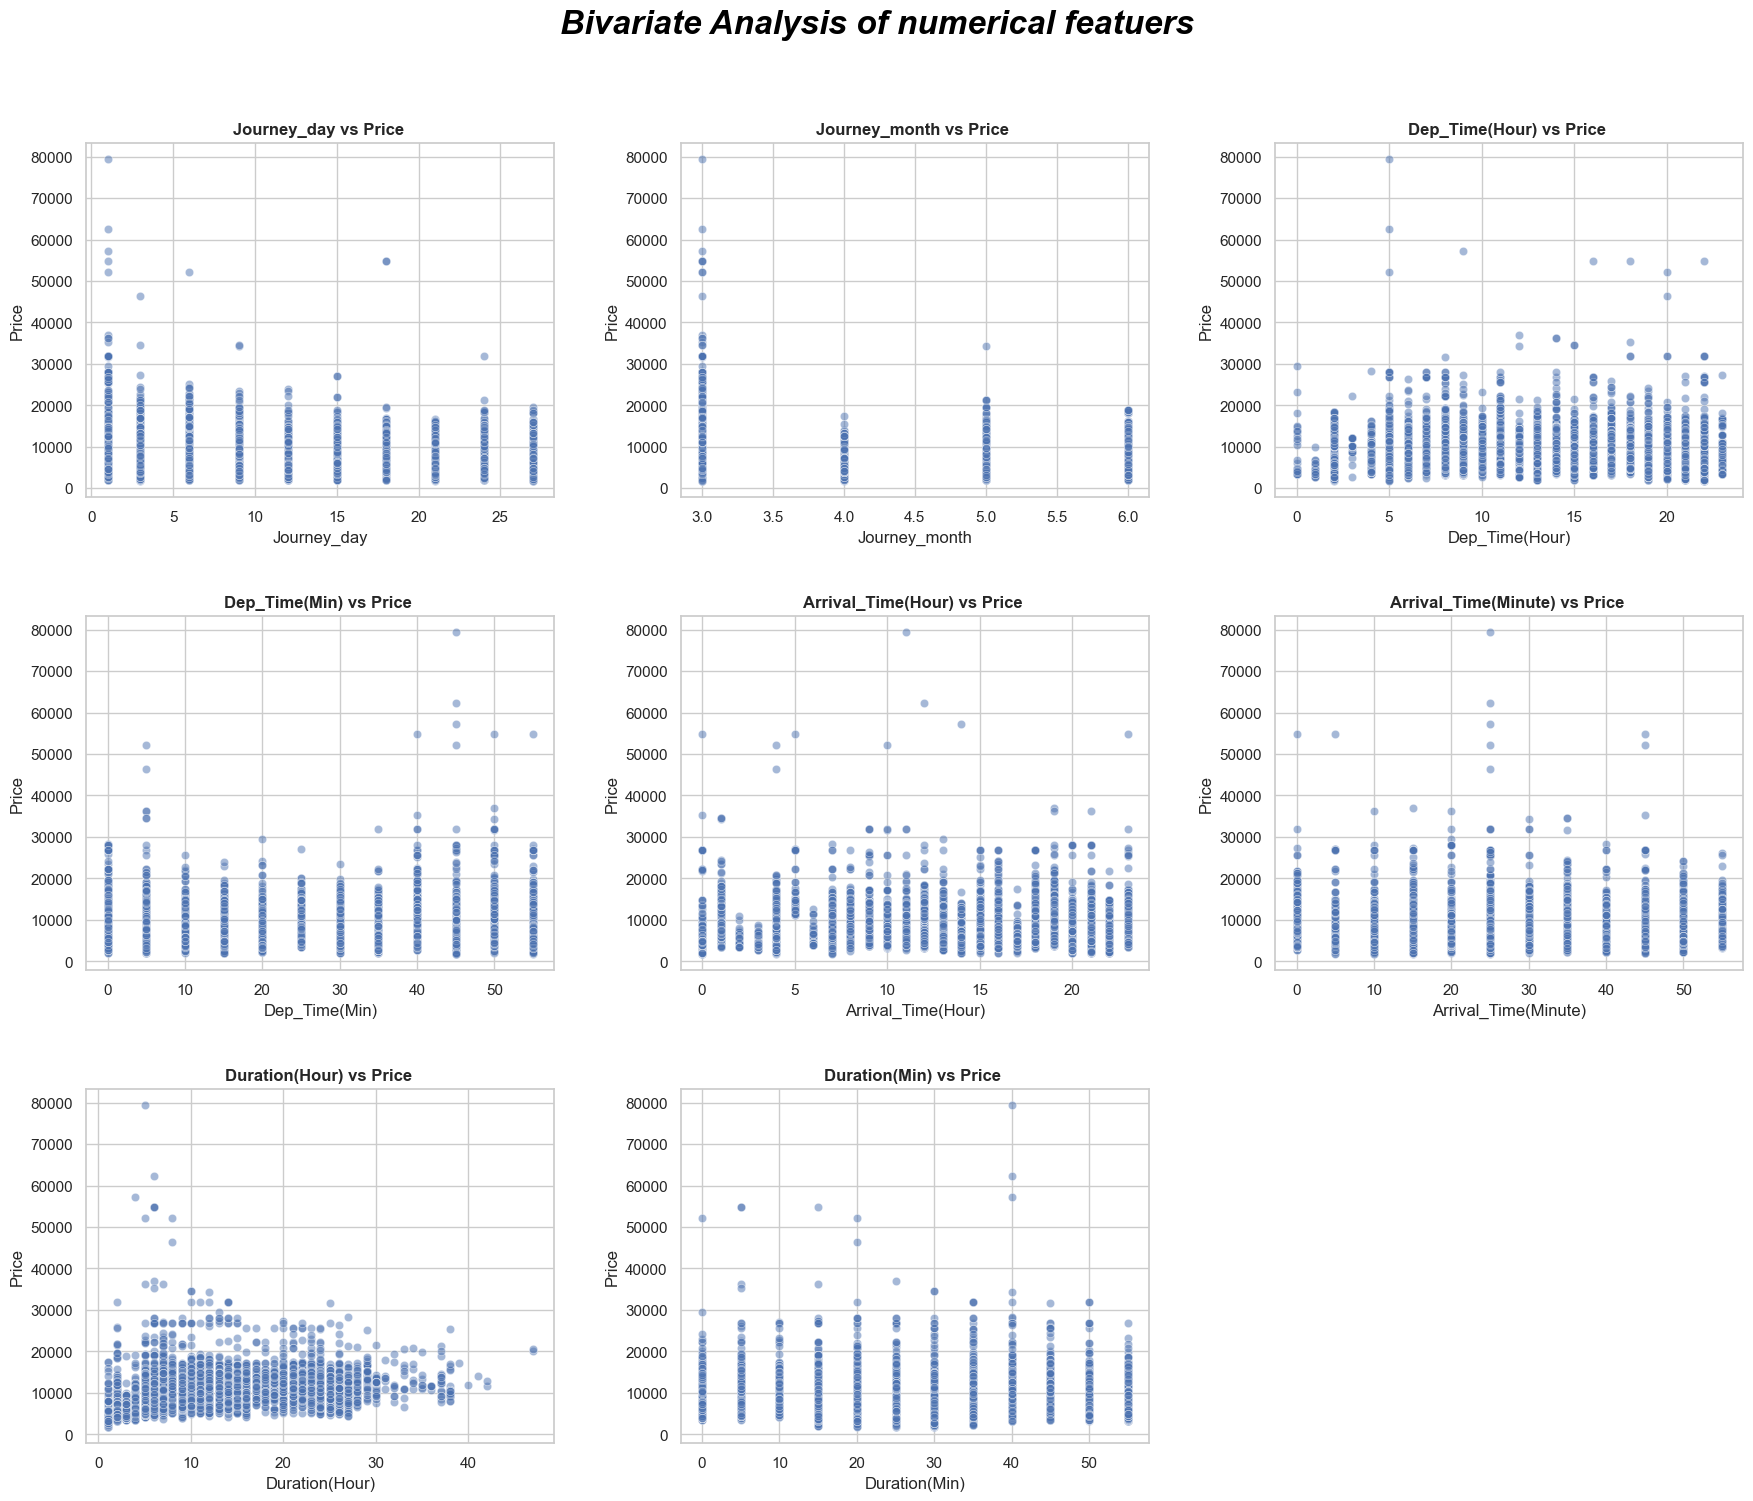

In [107]:
import math
from utils import  bivariate_plots,bivariate_cat_plots
bivariate_plots(df)

#  Bivariate Analysis Summary

##  Numerical Features vs Price

| Feature              | Observation |
|----------------------|-------------|
| **Journey_day**       | Prices are spread across all days. No specific day shows significantly higher or lower prices. |
| **Journey_month**     | All flights occur between March and June. Prices slightly increase in May and June, possibly due to seasonal demand. |
| **Dep_Time(Hour)**    | Slight increase in prices during midnight and early morning (1–6 AM). Could be used for time-of-day binning. |
| **Dep_Time(Min)**     | No clear pattern. Appears noisy. Can be dropped. |
| **Arrival_Time(Hour)**| Weak trend. No strong relationship observed. Consider binning into time-of-day categories. |
| **Arrival_Time(Min)** | No significant pattern. Appears random. Can be dropped. |
| **Duration(Hour)**    | Strong positive correlation. Longer flights tend to be more expensive. Very useful feature. |
| **Duration(Min)**     | No clear trend. Mostly noise. Can be dropped. |

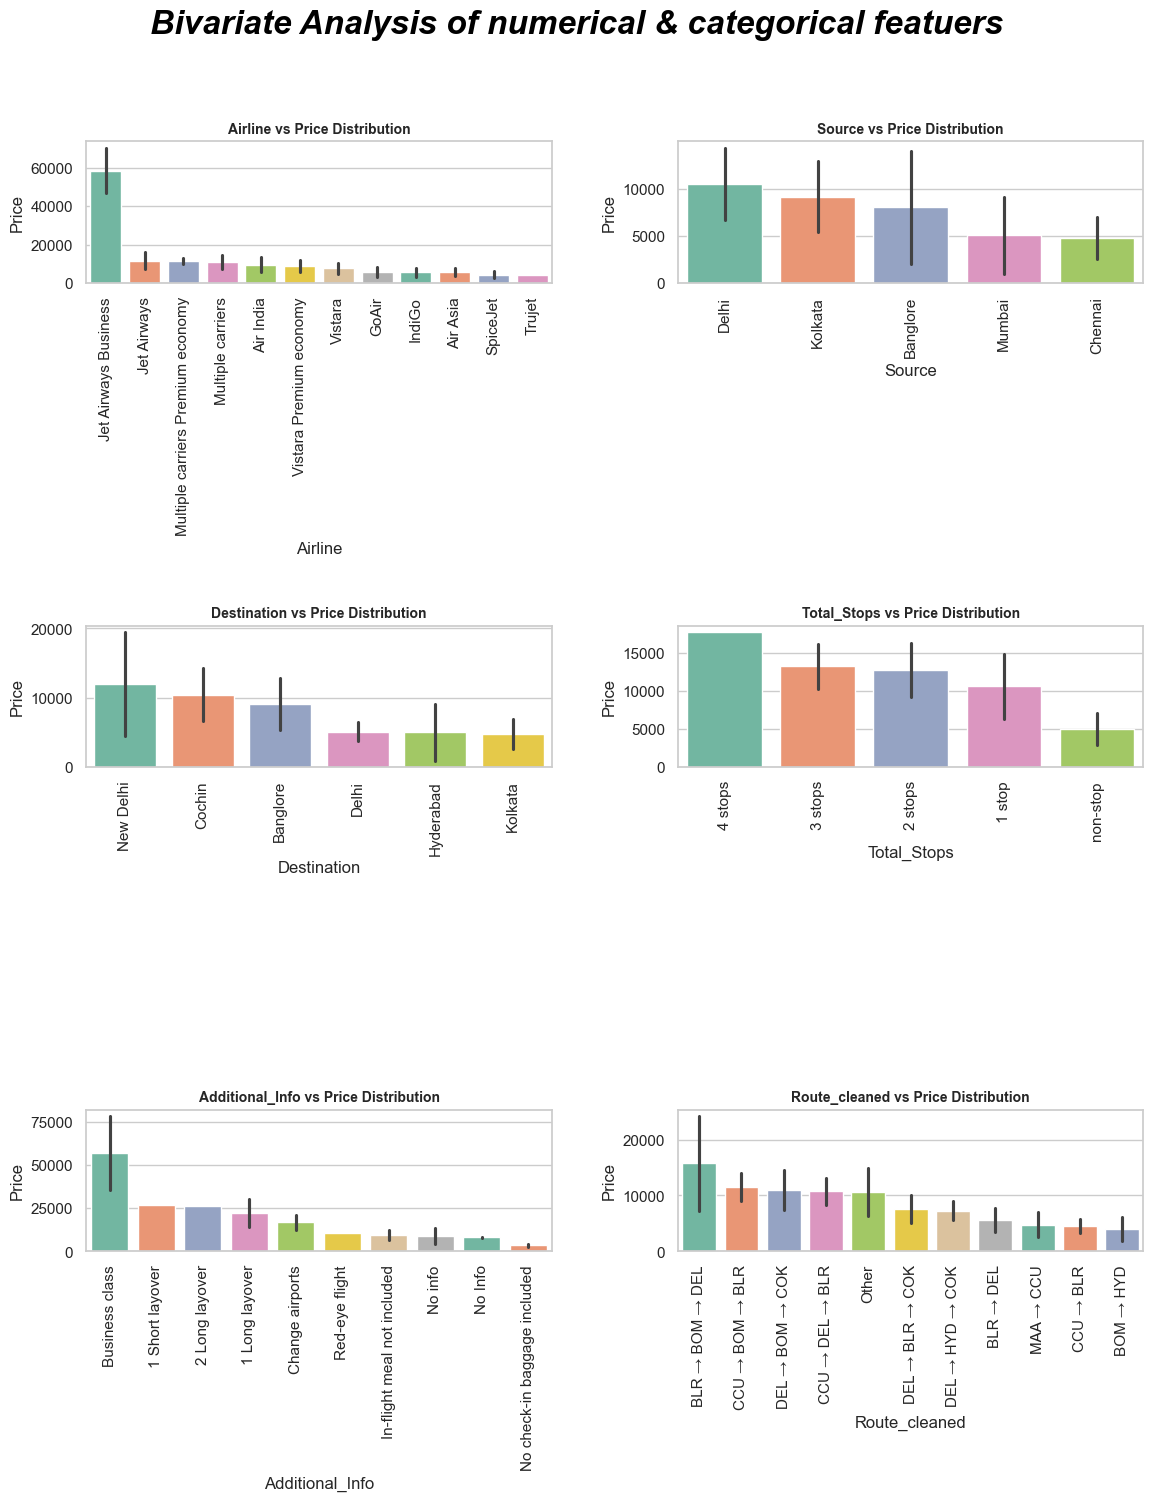

In [108]:
bivariate_cat_plots(df)

## Categorical Features vs Price

Here we analyze the mean price per category using barplots. Error bars (black lines) represent the **standard deviation** of prices for each category (`ci='sd'`).

| Feature             | Observation |
|---------------------|--------------|
| **Airline**          | Jet Airways Business and Premium carriers have the highest prices. Low-cost airlines (IndiGo, SpiceJet, Trujet) show lower average prices. |
| **Source**           | Flights from Delhi and Kolkata are generally more expensive. Mumbai and Chennai are the cheapest. |
| **Destination**      | New Delhi is the most expensive destination. Other destinations like Cochin, Hyderabad, and Kolkata are cheaper. |
| **Total_Stops**      | As expected, more stops lead to higher prices. Non-stop flights are the cheapest, while 3–4 stop flights are the most expensive. |
| **Additional_Info**  | "Business class" and "long layovers" are costly. Categories like "No check-in baggage" and "No info" are associated with cheaper fares. |
| **Route_cleaned**    | Routes involving multiple stops or popular destinations have higher average prices. Custom route features may improve model performance.

###  What do the error bars mean?
- Error bars on the bars represent **standard deviation (variability)** in flight prices for that category.
- **Visible error bars** → Higher variation or sample size.
- **No visible bars** → Low variability or very small number of samples.

In [109]:
#Dropping featuers where ever minutes are considerd:
df.drop(columns=['Dep_Time(Min)','Arrival_Time(Minute)','Duration(Min)','Airline', 'Route'],axis=1,inplace=True)

##  Multivariate Analysis

###  Pairplot of Selected Numerical Features

Pairplots help us understand how multiple numerical features relate to each other and to the target (`Price`). It reveals trends like linear or non-linear relationships, outliers, or feature groupings.

We selected only a subset of numerical features for clarity. The diagonal plots show distributions, while the scatter plots reveal correlations.

<Figure size 2000x1500 with 0 Axes>

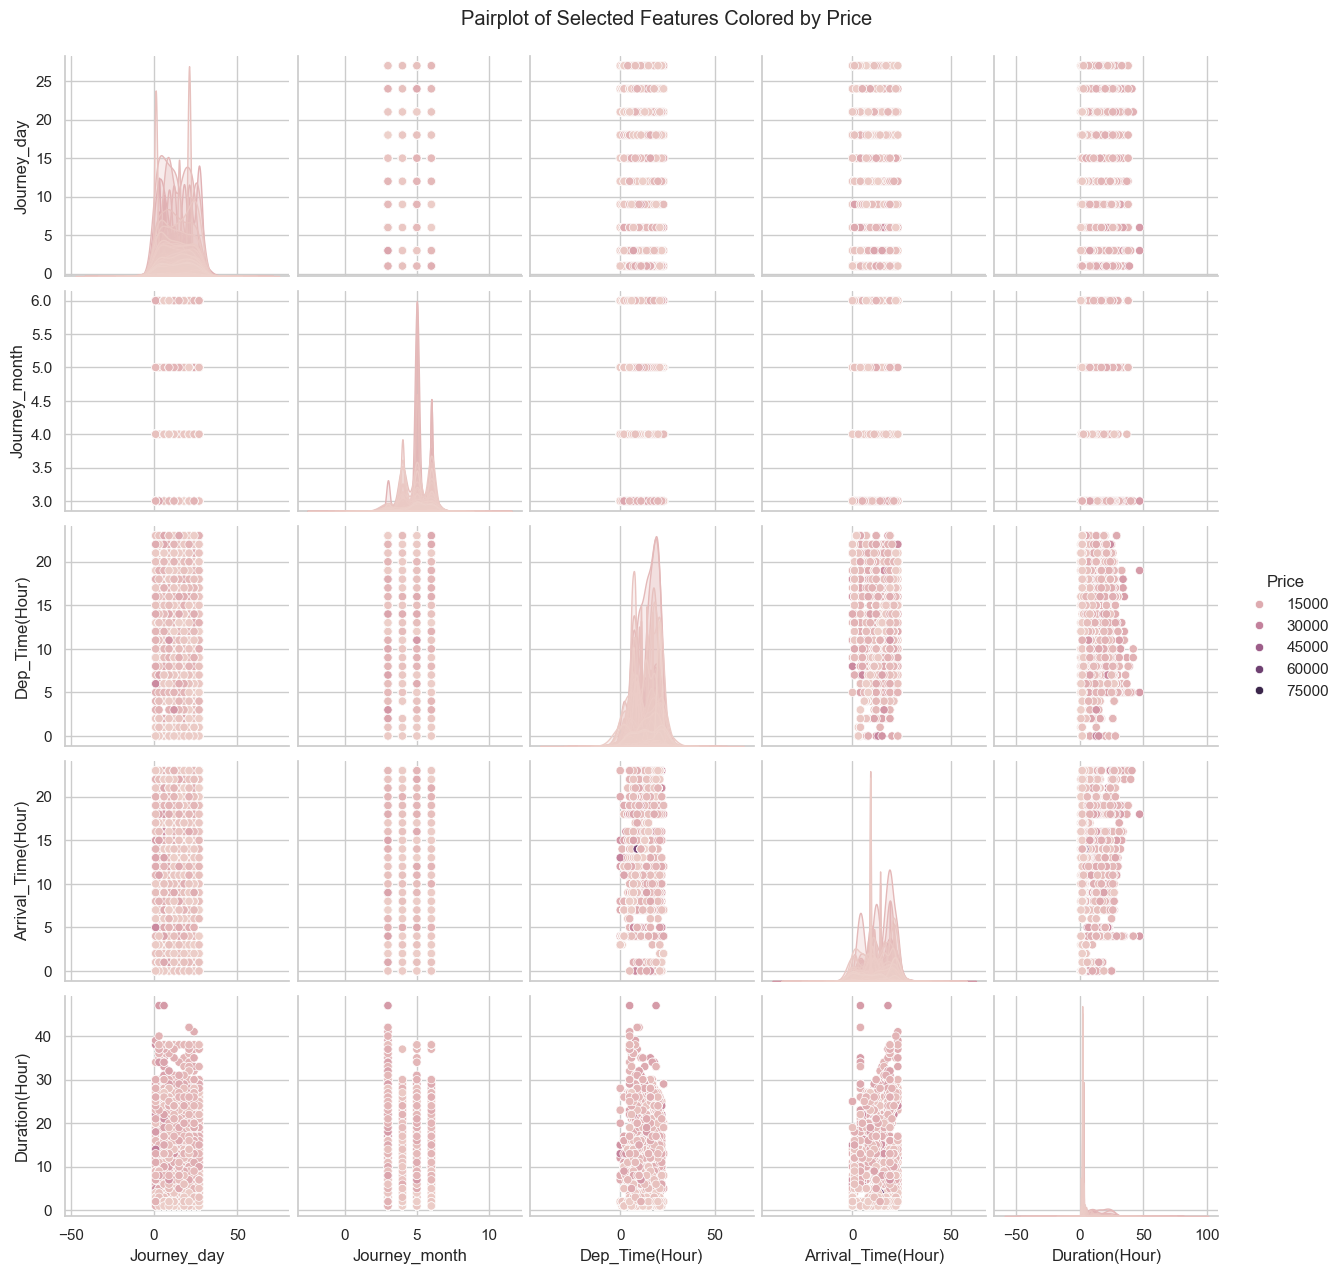

In [110]:
#Multivariate pairplot:
plt.figure(figsize=(20,15))
sns.pairplot(df, hue='Price')
plt.suptitle("Pairplot of Selected Features Colored by Price", y=1.02)
plt.show()

###  Correlation Heatmap

The heatmap below displays the pairwise correlation coefficients between all numerical variables.

- Values closer to `1` indicate a strong positive correlation.
- Values closer to `-1` indicate a strong negative correlation.
- Values near `0` indicate weak or no linear correlation.

This helps us identify multicollinearity and decide which features might be redundant or highly influential on `Price`.

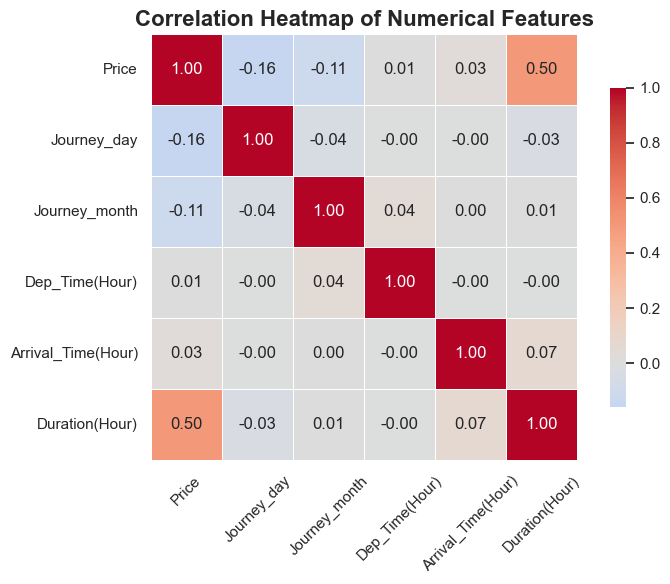

In [111]:
from utils import plot_correlation_heatmap
plot_correlation_heatmap(df)

### Data Preprocessing and Feature Engineering :

In [112]:
# Handling NAN Values:
print(df.isnull().sum())


Source                0
Destination           0
Total_Stops           0
Additional_Info       0
Price                 0
Journey_day           0
Journey_month         0
Dep_Time(Hour)        0
Arrival_Time(Hour)    0
Duration(Hour)        0
Airline_cleaned       0
Route_cleaned         0
dtype: int64


In [113]:
from utils import  assign_time_bin,detect_outliers_iqr,plot_boxplots
df['Dep_Time_Bin'] = df['Dep_Time(Hour)'].apply(assign_time_bin)
df['Arrival_Time_Bin'] = df['Arrival_Time(Hour)'].apply(assign_time_bin)

In [114]:
## Detecing outliers :
detect_outliers_iqr(df,df.select_dtypes(exclude='O').columns)

 Outlier Summary (IQR Method):



,Column,Outlier Count,Outlier Percentage
0,Price,94,0.90
1,Journey_day,0,0.00
2,Journey_month,0,0.00
3,Dep_Time(Hour),0,0.00
4,Arrival_Time(Hour),0,0.00
5,Duration(Hour),67,0.64


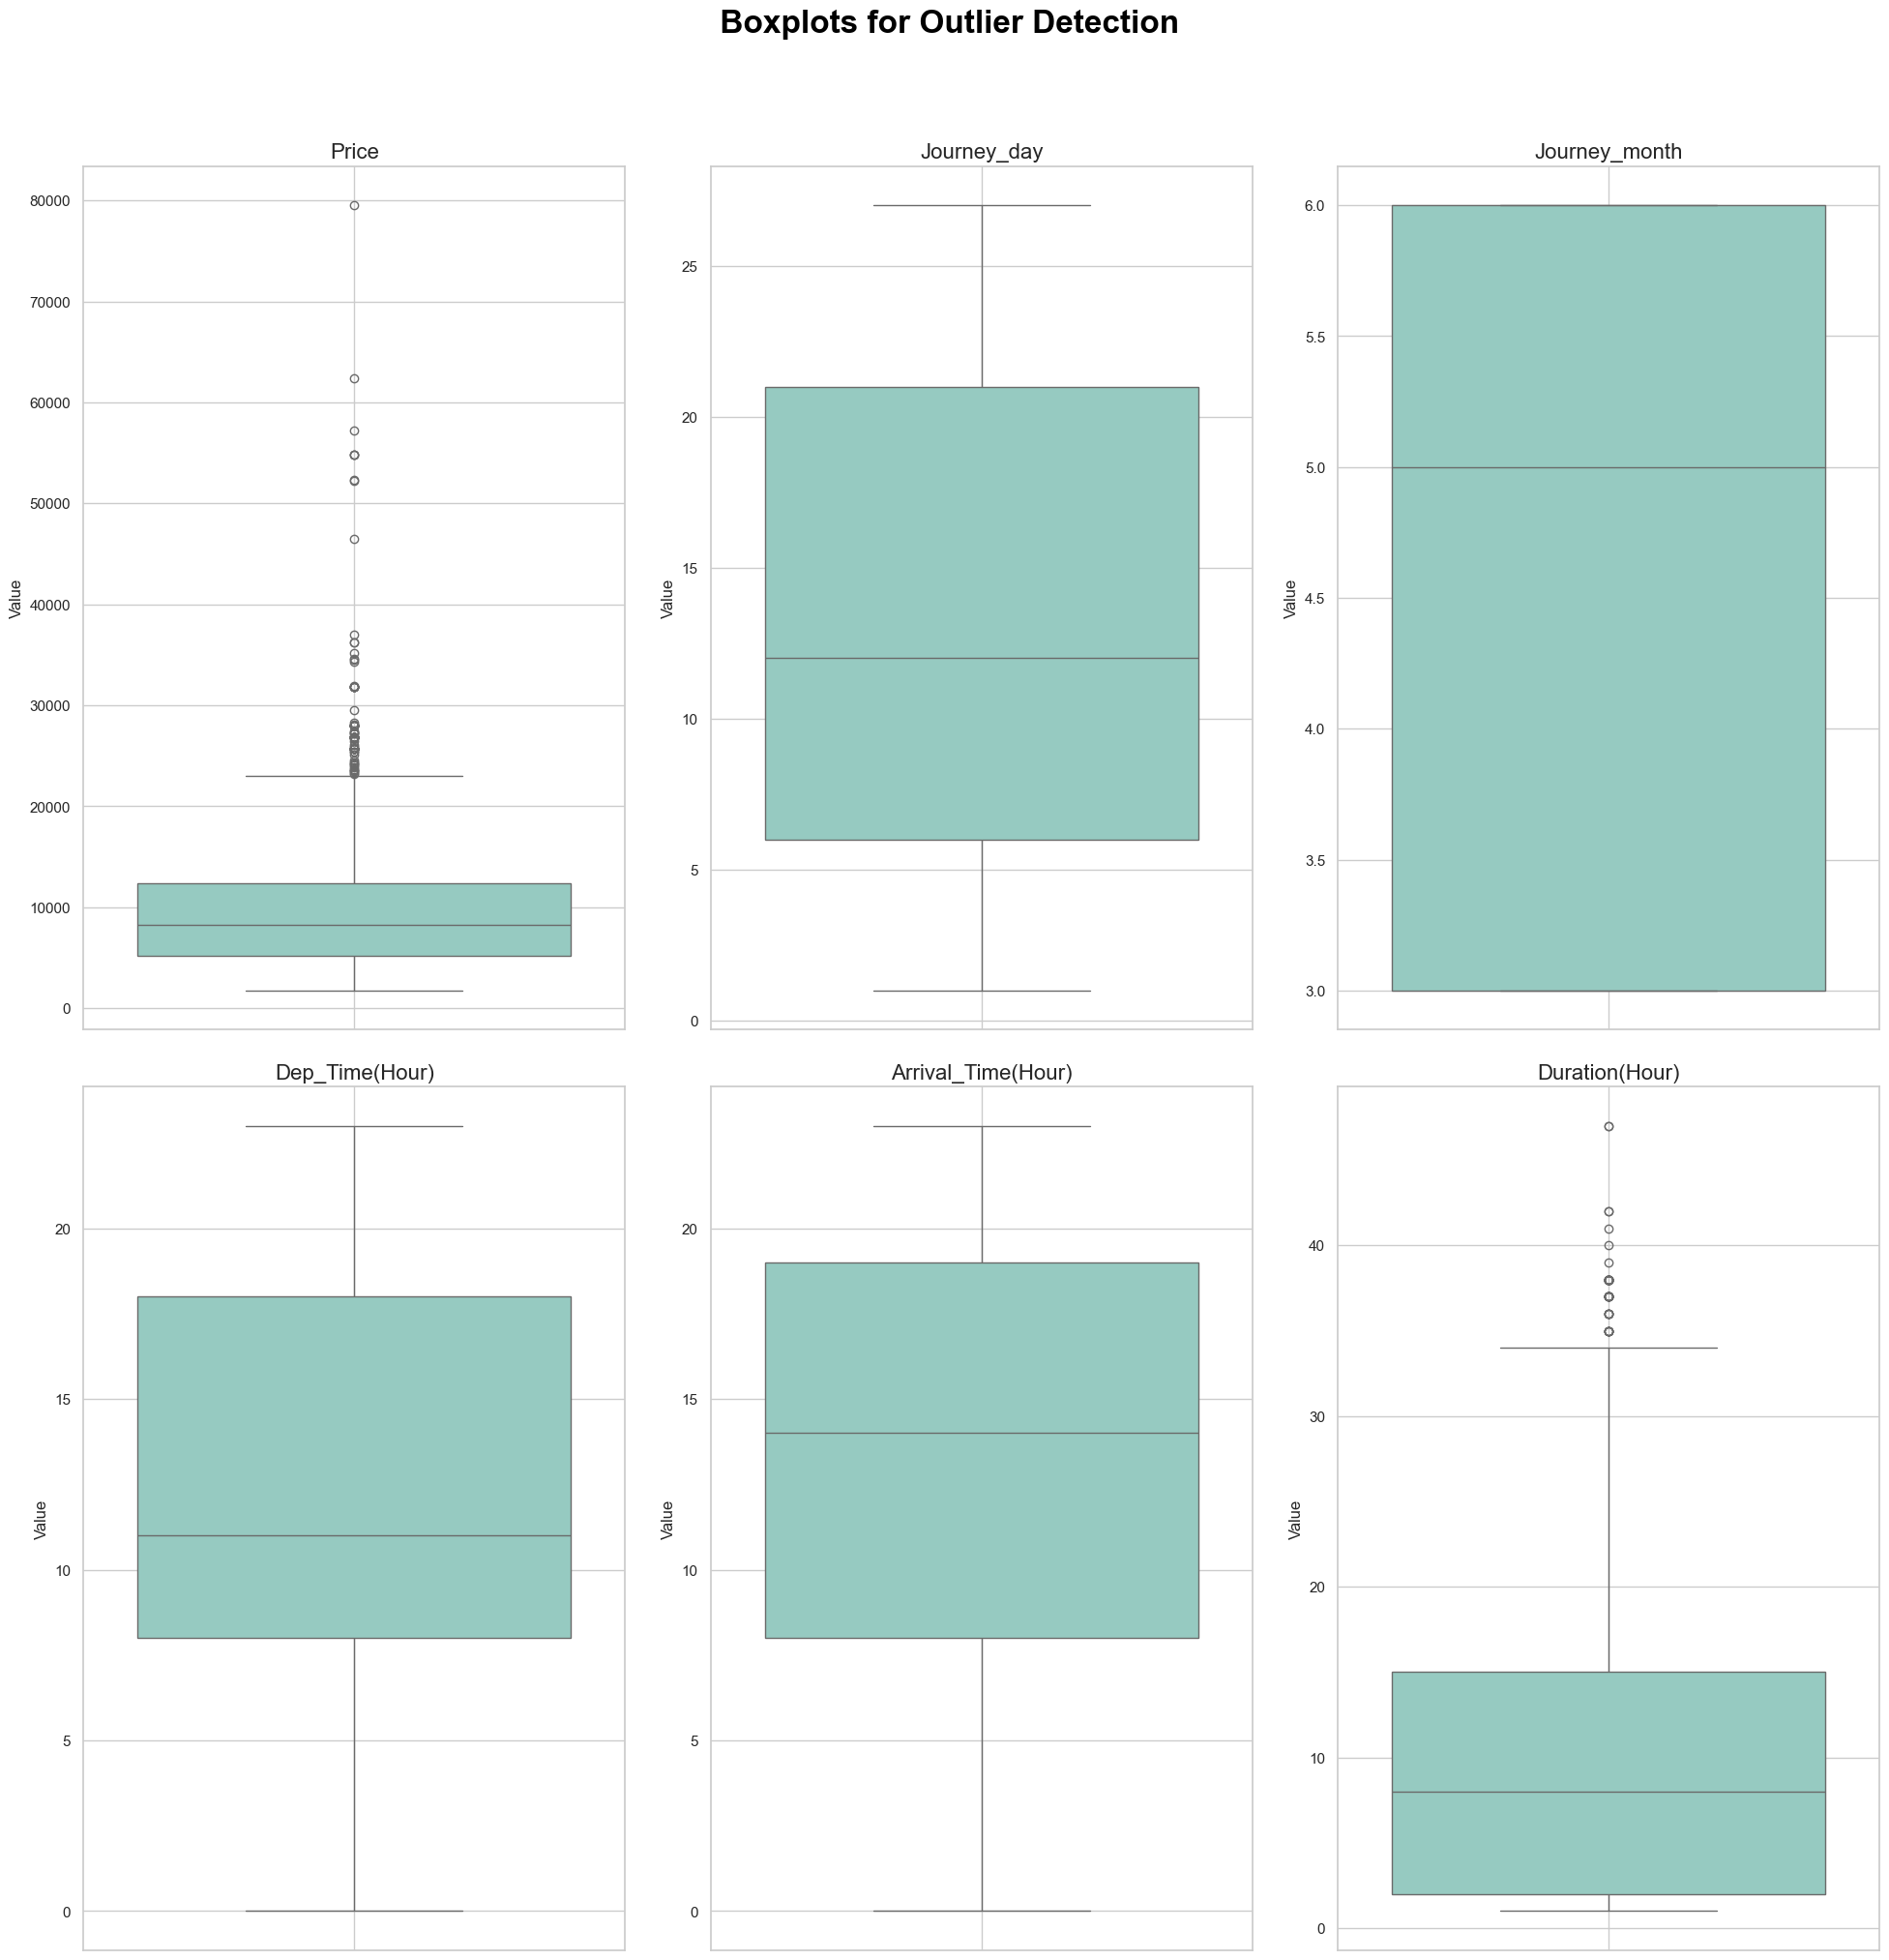

In [115]:
plot_boxplots(df,df.select_dtypes(exclude='O').columns)

In [116]:
# Duplicate records having "Delhi" & "New Delhi" are same, so we are merging them : 
df['Destination'].value_counts()

Destination
Cochin       4345
Banglore     2860
Delhi        1265
New Delhi     914
Hyderabad     697
Kolkata       381
Name: count, dtype: int64

In [117]:
df['Destination'] = df['Destination'].replace('New Delhi', 'Delhi')
df['Destination'].value_counts()

Destination
Cochin       4345
Banglore     2860
Delhi        2179
Hyderabad     697
Kolkata       381
Name: count, dtype: int64

In [118]:
df['Additional_Info'].value_counts()

Additional_Info
No info                         8182
In-flight meal not included     1926
No check-in baggage included     318
1 Long layover                    19
Change airports                    7
Business class                     4
No Info                            3
1 Short layover                    1
Red-eye flight                     1
2 Long layover                     1
Name: count, dtype: int64

In [119]:
#Simplify the feature by grouping rare categories:
df['Additional_Info'] = df['Additional_Info'].replace({
    'No Info': 'No info',
    '1 Long layover': 'Other',
    'Change airports': 'Other',
    'Business class': 'Other',
    '1 Short layover': 'Other',
    'Red-eye flight': 'Other',
    '2 Long layover': 'Other'
})


In [120]:
df['Additional_Info'].value_counts()

Additional_Info
No info                         8185
In-flight meal not included     1926
No check-in baggage included     318
Other                             33
Name: count, dtype: int64

In [121]:
df['Arrival_Time_Bin'].value_counts()

Arrival_Time_Bin
Night        3562
Evening      2631
Morning      2259
Afternoon    2010
Name: count, dtype: int64

In [122]:
df

,Source,Destination,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Dep_Time(Hour),Arrival_Time(Hour),Duration(Hour),Airline_cleaned,Route_cleaned,Dep_Time_Bin,Arrival_Time_Bin
0,Banglore,Delhi,non-stop,No info,3897,24,3,22,1,2,IndiGo,BLR → DEL,Night,Night
1,Kolkata,Banglore,2 stops,No info,7662,1,5,5,13,7,Air India,Other,Morning,Afternoon
2,Delhi,Cochin,2 stops,No info,13882,9,6,9,4,19,Jet Airways,Other,Morning,Night
3,Kolkata,Banglore,1 stop,No info,6218,12,5,18,23,5,IndiGo,Other,Evening,Night
4,Banglore,Delhi,1 stop,No info,13302,1,3,16,21,4,IndiGo,Other,Afternoon,Night
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Kolkata,Banglore,non-stop,No info,4107,9,4,19,22,2,Air Asia,CCU → BLR,Evening,Night
10679,Kolkata,Banglore,non-stop,No info,4145,27,4,20,23,2,Air India,CCU → BLR,Evening,Night
10680,Banglore,Delhi,non-stop,No info,7229,27,4,8,11,3,Jet Airways,BLR → DEL,Morning,Morning
10681,Banglore,Delhi,non-stop,No info,12648,1,3,11,14,2,Vistara,BLR → DEL,Morning,Afternoon


In [123]:
# Drop Unnecessary Columns :
df.drop(['Dep_Time(Hour)', 'Arrival_Time(Hour)'], axis=1, inplace=True)

In [124]:
# Frequency encoding for Route_cleaned
route_freq =df['Route_cleaned'].value_counts()
df['Route_cleaned_FREQ'] =df['Route_cleaned'].map(route_freq)
df.drop('Route_cleaned',axis=1,inplace=True)

In [125]:
# One-Hot Encode the following nominal featuers ('Source','Destination','Additional_Info'):
df =pd.get_dummies(df, columns=['Source','Destination','Additional_Info'], drop_first=True)

In [128]:
# Mapping the ordinal featuers with orderd basis:
ordinal_cols=['Total_Stops','Dep_Time_Bin','Arrival_Time_Bin']
ordinal_mappings={
    'Total_Stops':{'non-stop':0,'1 stop':1,'2 stops':2,'3 stops':3,'4 stops':4},
    'Dep_Time_Bin':{'Morning':0,'Afternoon':1,'Evening':2,'Night':3},
    'Arrival_Time_Bin':{'Morning':0,'Afternoon':1,'Evening':2,'Night':3}
}

for col,order in ordinal_mappings.items():
    df[col]=df[col].map(order)
    


In [129]:
#convert these bool values to numeric (0/1):
bool_cols =df.select_dtypes(include='bool').columns
df[bool_cols] =df[bool_cols].astype(int)

## Save the preprocessed data :

In [130]:
try:
    file_path=os.path.join(os.path.dirname(os.getcwd()),'data','preprocessed')
    os.makedirs(file_path,exist_ok=True)
    df.to_csv(os.path.join(file_path,'preprocessed_df.csv'),index=False)
    print('preprocessed_df.csv file is saved succesfully...')
except Exception as e:
    raise f'Exception occured : {str(e)}'

preprocessed_df.csv file is saved succesfully...
